# UR10 Simple Reach — Training & Rollout

6-DOF arm only. No gripper, no box. Reaches a randomly placed 3D target.

**Observation (18D)** matches RDTE receive package:
```
q[6]          — arm joint positions (rad)       → RDTE getActualQ()
qd[6]         — arm joint velocities (rad/s)    → RDTE getActualQd()
tcp_pos[3]    — TCP Cartesian position (m)      → RDTE getActualTCPPose()[:3]
target_pos[3] — goal position (m)               — provided externally
```
**Action (6D):** delta joint position commands for each arm joint.

## 1 — Backend setup (CPU / GPU / macOS)

In [33]:
import os
import platform
import subprocess

# Must be set BEFORE importing JAX
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"

def is_nvidia_available():
    try:
        r = subprocess.run(["nvidia-smi"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=5)
        return r.returncode == 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False

system = platform.system()
if system == "Darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
    print("macOS detected — MUJOCO_GL=glfw, JAX on CPU")
elif is_nvidia_available():
    os.environ["MUJOCO_GL"] = "egl"
    print("NVIDIA GPU detected — MUJOCO_GL=egl")
else:
    os.environ["MUJOCO_GL"] = "osmesa"
    os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
    print("No GPU — MUJOCO_GL=osmesa, JAX on CPU")

macOS detected — MUJOCO_GL=glfw, JAX on CPU


## 2 — Imports

In [34]:
import functools
import json
import pickle
import time
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
from IPython.display import clear_output, display

from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo

from mujoco_playground import registry, wrapper
from mujoco_playground.config import manipulation_params

import jax, mujoco, brax, flax
print("JAX:", jax.__version__)
print("MuJoCo:", mujoco.__version__)
print("Brax:", brax.__version__)
print("Flax:", flax.__version__)
print("JAX devices:", jax.devices())

JAX: 0.6.2
MuJoCo: 3.3.6
Brax: 0.13.0
Flax: 0.10.7
JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


## 3 — Load environment & inspect

In [35]:
env_name = "UR10SimpleReach"
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

print(f"\n--- {env_name} ---")
print(f"  nq (joint positions) : {env.mj_model.nq}")   # expect 6
print(f"  nv (joint velocities): {env.mj_model.nv}")   # expect 6
print(f"  nu (actuators)       : {env.mj_model.nu}")   # expect 6
print(f"  action_size          : {env.action_size}")

✓ Using keyframe: 'low_home'
  Initial qpos size: 6
  Robot joints: [ 0.   -1.7   2.25 -2.15 -1.5  -1.5 ]

--- UR10SimpleReach ---
  nq (joint positions) : 6
  nv (joint velocities): 6
  nu (actuators)       : 6
  action_size          : 6


In [36]:
# Verify observation shape
rng = jax.random.PRNGKey(0)
state = env.reset(rng)

obs = state.obs
print(f"obs shape  : {obs.shape}")          # expect (18,)
print(f"obs q      : {np.array(obs[0:6]).round(3)}")   # arm joint pos
print(f"obs qd     : {np.array(obs[6:12]).round(3)}")  # arm joint vel
print(f"obs tcp_pos: {np.array(obs[12:15]).round(3)}") # TCP xyz
print(f"obs target : {np.array(obs[15:18]).round(3)}") # target xyz
print(f"tcp→target dist: {np.linalg.norm(np.array(obs[15:18]) - np.array(obs[12:15])):.4f} m")

obs shape  : (18,)
obs q      : [ 0.04  -1.659  2.234 -2.178 -1.485 -1.499]
obs qd     : [0. 0. 0. 0. 0. 0.]
obs tcp_pos: [0. 0. 0.]
obs target : [ 0.304 -0.383  0.549]
tcp→target dist: 0.7351 m


## 4 — MuJoCo viewer (passive, CPU render)
Opens a live viewer of the reset pose. Close window to continue.

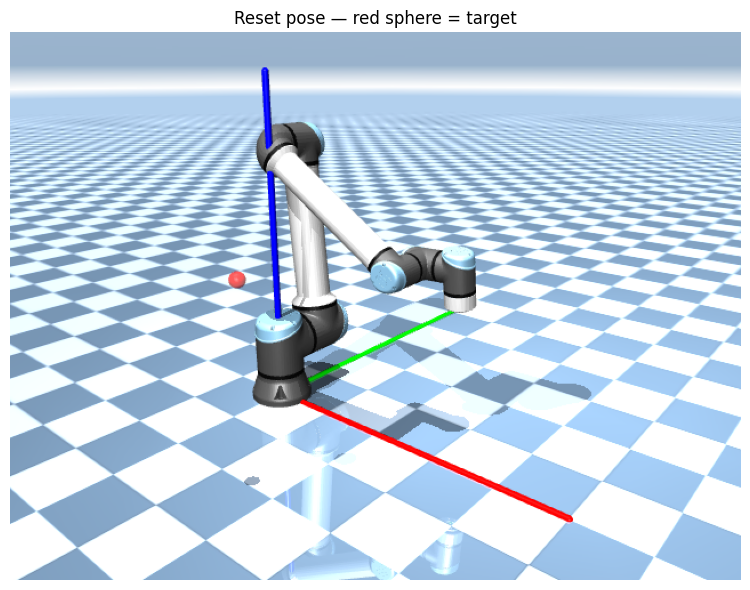

In [37]:
xml_path = "../../mujoco_playground/_src/manipulation/my_ur10/xmls/mjx_reach.xml"
mj_model = mujoco.MjModel.from_xml_path(xml_path)
mj_data = mujoco.MjData(mj_model)

# Copy reset state into standard MuJoCo data
mj_data.qpos[:] = np.array(state.data.qpos)
mj_data.qvel[:] = np.array(state.data.qvel)
mj_data.mocap_pos[:] = np.array(state.data.mocap_pos)
mujoco.mj_forward(mj_model, mj_data)

# Render a single frame
renderer = mujoco.Renderer(mj_model, height=480, width=640)
cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat[:] = [0.4, 0.0, 0.4]
cam.distance = 1.8
cam.azimuth = 130
cam.elevation = -20

renderer.update_scene(mj_data, camera=cam)
img = renderer.render()
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Reset pose — red sphere = target")
plt.tight_layout()
plt.show()

## 5 — PPO Training

In [38]:
ppo_params = manipulation_params.brax_ppo_config(env_name)
ppo_params

action_repeat: 1
batch_size: 512
discounting: 0.97
entropy_cost: 0.02
episode_length: 150
learning_rate: 0.001
network_factory:
  policy_hidden_layer_sizes: !!python/tuple
  - 64
  - 64
  - 64
  policy_obs_key: state
  value_hidden_layer_sizes: !!python/tuple
  - 256
  - 256
  - 256
  - 256
  - 256
  value_obs_key: state
normalize_observations: true
num_envs: 2048
num_evals: 5
num_minibatches: 32
num_resets_per_eval: 10
num_timesteps: 10000000
num_updates_per_batch: 8
reward_scaling: 1.0
unroll_length: 10

In [39]:
# Optional: override params for a quick test run
fast_params = deepcopy(ppo_params)
fast_params["num_timesteps"] = 5_000_000   # uncomment for a quick smoke-test
# fast_params["num_evals"] = 2
ppo_params = fast_params
print("num_timesteps:", ppo_params["num_timesteps"])

num_timesteps: 5000000


In [40]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

def progress(num_steps, metrics):
    clear_output(wait=True)
    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"UR10SimpleReach  reward={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
    display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

train_fn = functools.partial(
    ppo.train,
    **ppo_training_params,
    network_factory=network_factory,
    progress_fn=progress,
    seed=1,
)

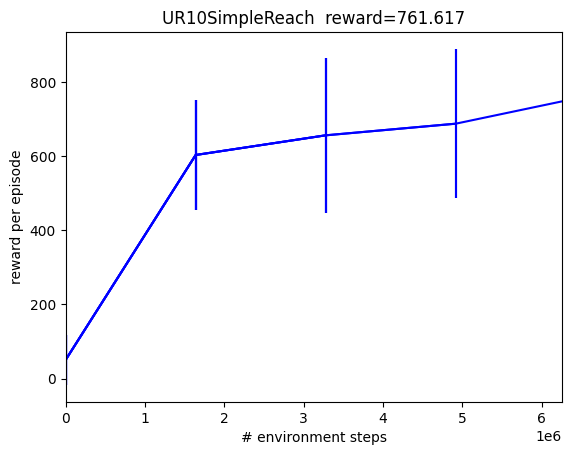

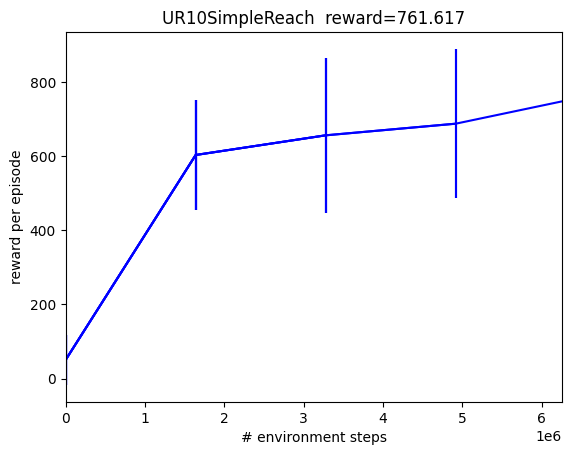

In [41]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
best_idx = int(np.argmax(y_data)) if y_data else 0

In [42]:
print(f"JIT time  : {times[1] - times[0]}")
print(f"Train time: {times[-1] - times[1]}")
if y_data:
    print(f"Best reward: {y_data[best_idx]:.3f} ± {y_dataerr[best_idx]:.3f} at step {x_data[best_idx]}")

JIT time  : 0:00:12.644278
Train time: 0:03:35.265528
Best reward: 761.617 ± 119.123 at step 6553600


## 6 — Policy rollout & visualisation

In [43]:
jit_reset = jax.jit(env.reset)
jit_step  = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

rng = jax.random.PRNGKey(42)
state = jit_reset(rng)

# MuJoCo renderer
mj_model = mujoco.MjModel.from_xml_path(xml_path)
mj_data  = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model, height=480, width=640)

cam = mujoco.MjvCamera()
cam.type     = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat[:] = [0.4, 0.0, 0.4]
cam.distance  = 1.8
cam.azimuth   = 130
cam.elevation = -20

num_steps   = 150
render_every = 2
frames = []
tcp_positions = []
rewards = []

for t in range(num_steps):
    action, _ = jit_inference_fn(state.obs, rng)
    state = jit_step(state, action)

    rewards.append(float(state.reward))
    tcp_pos = np.array(state.obs[12:15])
    target  = np.array(state.obs[15:18])
    tcp_positions.append(tcp_pos.copy())

    # Sync to standard MuJoCo for rendering
    mj_data.qpos[:]      = np.array(state.data.qpos)
    mj_data.qvel[:]      = np.array(state.data.qvel)
    mj_data.ctrl[:]      = np.array(state.data.ctrl)
    mj_data.mocap_pos[:] = np.array(state.data.mocap_pos)
    mujoco.mj_forward(mj_model, mj_data)

    if t % render_every == 0:
        renderer.update_scene(mj_data, camera=cam)
        frames.append(renderer.render().copy())

    if float(state.done) > 0.0:
        print(f"Episode ended at step {t+1}")
        break

print(f"Collected {len(frames)} frames.")
final_dist = np.linalg.norm(target - tcp_positions[-1])
print(f"Final TCP→target distance: {final_dist*100:.1f} cm")

Collected 75 frames.
Final TCP→target distance: 5.6 cm


In [44]:
# Inline video
media.show_video(frames, fps=30, height=480)

This browser does not support the video tag.


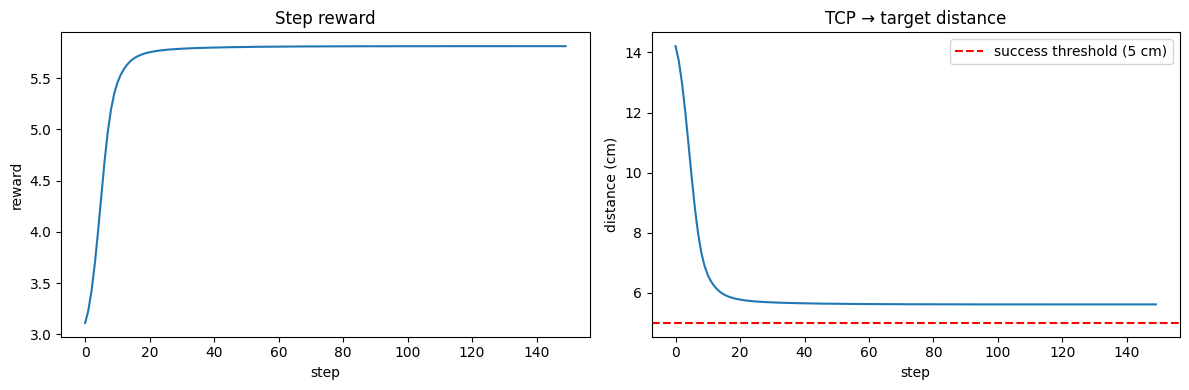

In [45]:
tcp_arr    = np.array(tcp_positions)                        # (T, 3)
target_arr = np.array(state.obs[15:18])                    # (3,)
dist_arr   = np.linalg.norm(tcp_arr - target_arr, axis=1)  # (T,)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reward curve
axes[0].plot(rewards)
axes[0].set_title("Step reward")
axes[0].set_xlabel("step")
axes[0].set_ylabel("reward")

# Distance to target
axes[1].plot(dist_arr * 100)
axes[1].axhline(5.0, color="red", linestyle="--", label="success threshold (5 cm)")
axes[1].set_title("TCP → target distance")
axes[1].set_xlabel("step")
axes[1].set_ylabel("distance (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7 — Observation decomposition over rollout
Shows how each 18D obs component evolves — useful for debugging RDTE deployment.

obs_arr shape: (150, 18)


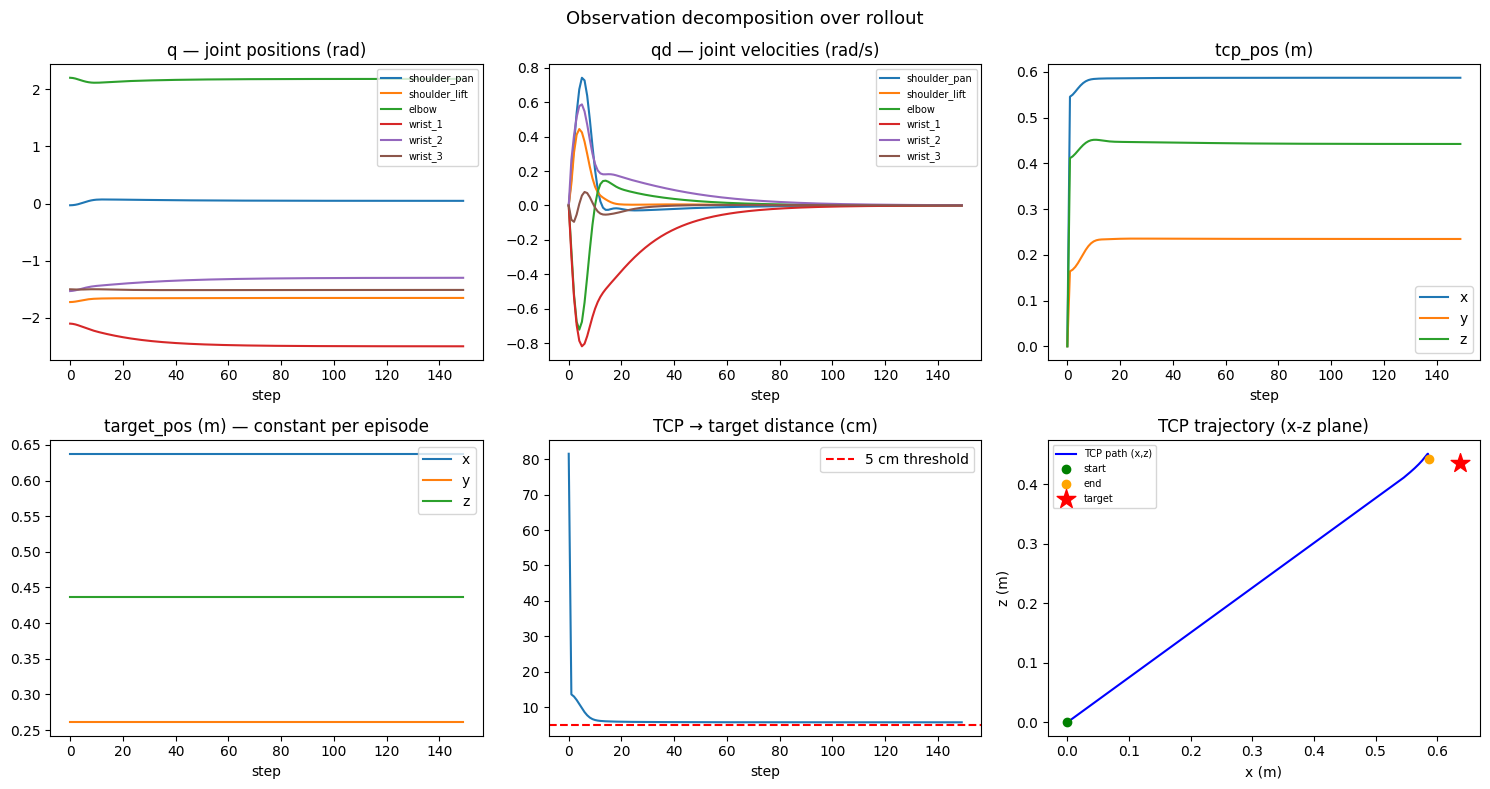

In [46]:
# Re-run a rollout and collect full obs history
rng = jax.random.PRNGKey(7)
state = jit_reset(rng)
obs_history = [np.array(state.obs)]

for _ in range(149):
    action, _ = jit_inference_fn(state.obs, rng)
    state = jit_step(state, action)
    obs_history.append(np.array(state.obs))
    if float(state.done) > 0.0:
        break

obs_arr = np.array(obs_history)  # (T, 18)
print("obs_arr shape:", obs_arr.shape)

JOINT_NAMES = ["shoulder_pan", "shoulder_lift", "elbow", "wrist_1", "wrist_2", "wrist_3"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# q (joint positions)
ax = axes[0, 0]
for i, name in enumerate(JOINT_NAMES):
    ax.plot(obs_arr[:, i], label=name)
ax.set_title("q — joint positions (rad)")
ax.legend(fontsize=7)
ax.set_xlabel("step")

# qd (joint velocities)
ax = axes[0, 1]
for i, name in enumerate(JOINT_NAMES):
    ax.plot(obs_arr[:, 6 + i], label=name)
ax.set_title("qd — joint velocities (rad/s)")
ax.legend(fontsize=7)
ax.set_xlabel("step")

# tcp_pos (xyz)
ax = axes[0, 2]
for i, label in enumerate(["x", "y", "z"]):
    ax.plot(obs_arr[:, 12 + i], label=label)
ax.set_title("tcp_pos (m)")
ax.legend()
ax.set_xlabel("step")

# target_pos (xyz) — constant within episode
ax = axes[1, 0]
for i, label in enumerate(["x", "y", "z"]):
    ax.plot(obs_arr[:, 15 + i], label=label)
ax.set_title("target_pos (m) — constant per episode")
ax.legend()
ax.set_xlabel("step")

# tcp → target distance
ax = axes[1, 1]
d = np.linalg.norm(obs_arr[:, 12:15] - obs_arr[:, 15:18], axis=1)
ax.plot(d * 100)
ax.axhline(5.0, color="red", linestyle="--", label="5 cm threshold")
ax.set_title("TCP → target distance (cm)")
ax.legend()
ax.set_xlabel("step")

# TCP trajectory in 3D
ax = axes[1, 2]
ax.plot(obs_arr[:, 12], obs_arr[:, 14], "b-", label="TCP path (x,z)")
ax.scatter(*obs_arr[0, [12, 14]], color="green", zorder=5, label="start")
ax.scatter(*obs_arr[-1, [12, 14]], color="orange", zorder=5, label="end")
ax.scatter(obs_arr[0, 15], obs_arr[0, 17], color="red", marker="*", s=200, zorder=5, label="target")
ax.set_title("TCP trajectory (x-z plane)")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.legend(fontsize=7)

plt.suptitle("Observation decomposition over rollout", fontsize=13)
plt.tight_layout()
plt.show()

## 8 — Save policy

In [47]:
save_dir = Path("../../evaluation/downloaded_policies/simple_reach_policy")
save_dir.mkdir(parents=True, exist_ok=True)

with open(save_dir / "params.pkl", "wb") as f:
    pickle.dump(params, f)

with open(save_dir / "metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

metadata = {
    "env_name": env_name,
    "obs_dim": int(env.observation_size),
    "action_dim": int(env.action_size),
    "obs_layout": "q[0:6], qd[6:12], tcp_pos[12:15], target_pos[15:18]",
    "branch": "simple_reach",
    "best_reward": float(y_data[best_idx]) if y_data else None,
    "best_step": int(x_data[best_idx]) if x_data else None,
    "notes": "6-DOF arm-only reach. No gripper, no box. 18D obs matching RDTE.",
}

with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to: {save_dir.resolve()}")
print(json.dumps(metadata, indent=2))

Saved to: /Users/matthiasweiss/Desktop/ZHAW/MSE/3_VT1_Model Based RL/My_Mujoco/my_mujoco_playground/evaluation/downloaded_policies/simple_reach_policy
{
  "env_name": "UR10SimpleReach",
  "obs_dim": 18,
  "action_dim": 6,
  "obs_layout": "q[0:6], qd[6:12], tcp_pos[12:15], target_pos[15:18]",
  "branch": "simple_reach",
  "best_reward": 761.6173706054688,
  "best_step": 6553600,
  "notes": "6-DOF arm-only reach. No gripper, no box. 18D obs matching RDTE."
}


## 9 — Reload & verify saved policy

In [48]:
with open(save_dir / "params.pkl", "rb") as f:
    loaded_params = pickle.load(f)

loaded_inference_fn = jax.jit(make_inference_fn(loaded_params, deterministic=True))

# Quick sanity rollout
rng = jax.random.PRNGKey(99)
state = jit_reset(rng)
action, _ = loaded_inference_fn(state.obs, rng)

print("Loaded policy output shape:", action.shape)  # expect (6,)
print("Action sample:", np.array(action).round(4))

Loaded policy output shape: (6,)
Action sample: [ 0.4634  0.4891 -0.6006 -0.6902  0.6382 -0.13  ]
